In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [49]:
def load_and_preprocess(file_path):
    df = pd.read_csv(file_path)

    df['time:timestamp'] = pd.to_datetime(
        df['time:timestamp'],
        errors='coerce',
        utc=True
    )

    df = df.dropna(subset=['time:timestamp'])

    df = df.sort_values(
        by=['case:concept:name', 'time:timestamp']
    )

    df['YearWeek'] = df['time:timestamp'].dt.strftime('%Y-W%V')

    return df

In [50]:
def extract_weekly_features(df):

    # ----- Control Flow -----
    df = df.copy()

    df['next_activity'] = (
        df.groupby('case:concept:name')['concept:name']
        .shift(-1)
    )

    df_transitions = df.dropna(
        subset=['next_activity']
    ).copy()

    df_transitions['transition'] = (
        df_transitions['concept:name']
        + " -> "
        + df_transitions['next_activity']
    )

    feature_dfg = (
        df_transitions
        .groupby(['YearWeek', 'transition'])
        .size()
        .unstack(fill_value=0)
    )

    # ----- Performance -----
    df_transitions['next_time'] = (
        df_transitions
        .groupby('case:concept:name')['time:timestamp']
        .shift(-1)
    )

    df_transitions['wait_time_hours'] = (
        (df_transitions['next_time']
         - df_transitions['time:timestamp'])
        .dt.total_seconds() / 3600
    )

    feature_wait_time = (
        df_transitions
        .groupby('YearWeek')['wait_time_hours']
        .mean()
        .rename('Mean_WaitTime_Hours')
    )

    # ----- Volume -----
    feature_event_volume = (
        df.groupby('YearWeek')
        .size()
        .rename('Event_Volume')
    )

    feature_active_cases = (
        df.groupby('YearWeek')['case:concept:name']
        .nunique()
        .rename('Active_Cases')
    )

    first_events = df.drop_duplicates(
        subset=['case:concept:name'],
        keep='first'
    )

    feature_arrival_rate = (
        first_events.groupby('YearWeek')
        .size()
        .rename('Arrival_Rate')
    )

    # ----- Data -----
    feature_requested_amount = (
        df.groupby('YearWeek')['case:RequestedAmount']
        .mean()
        .rename('Mean_RequestedAmount')
    )

    weekly_features = pd.concat([
        feature_dfg,
        feature_wait_time,
        feature_event_volume,
        feature_active_cases,
        feature_arrival_rate,
        feature_requested_amount
    ], axis=1).fillna(0)

    return weekly_features

In [51]:
def compute_similarity(weekly_features):

    weeks = weekly_features.index.tolist()

    scaler = MinMaxScaler()
    weekly_features_scaled = scaler.fit_transform(
        weekly_features
    )

    similarities = []

    for i in range(1, len(weeks)):
        sim = cosine_similarity(
            weekly_features_scaled[i-1].reshape(1, -1),
            weekly_features_scaled[i].reshape(1, -1)
        )[0][0]

        similarities.append(sim)

    mean_sim = np.mean(similarities)
    std_sim = np.std(similarities)

    threshold = mean_sim - 2 * std_sim

    drift_weeks = []

    for i, sim in enumerate(similarities):
        if sim < threshold:
            drift_weeks.append(weeks[i + 1])

    return weeks, similarities, threshold, drift_weeks

In [52]:
def plot_drift(
    weeks,
    similarities,
    threshold,
    drift_weeks,
    title
):

    plt.figure(figsize=(15, 6))

    plt.plot(
        weeks[1:],
        similarities,
        marker='o',
        linestyle='-',
        linewidth=2,
        label='Cosine Similarity'
    )

    plt.title(title)
    plt.xlabel("Year-Week")
    plt.ylabel("Cosine Similarity")
    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [53]:
# Đọc dữ liệu
df = load_and_preprocess("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

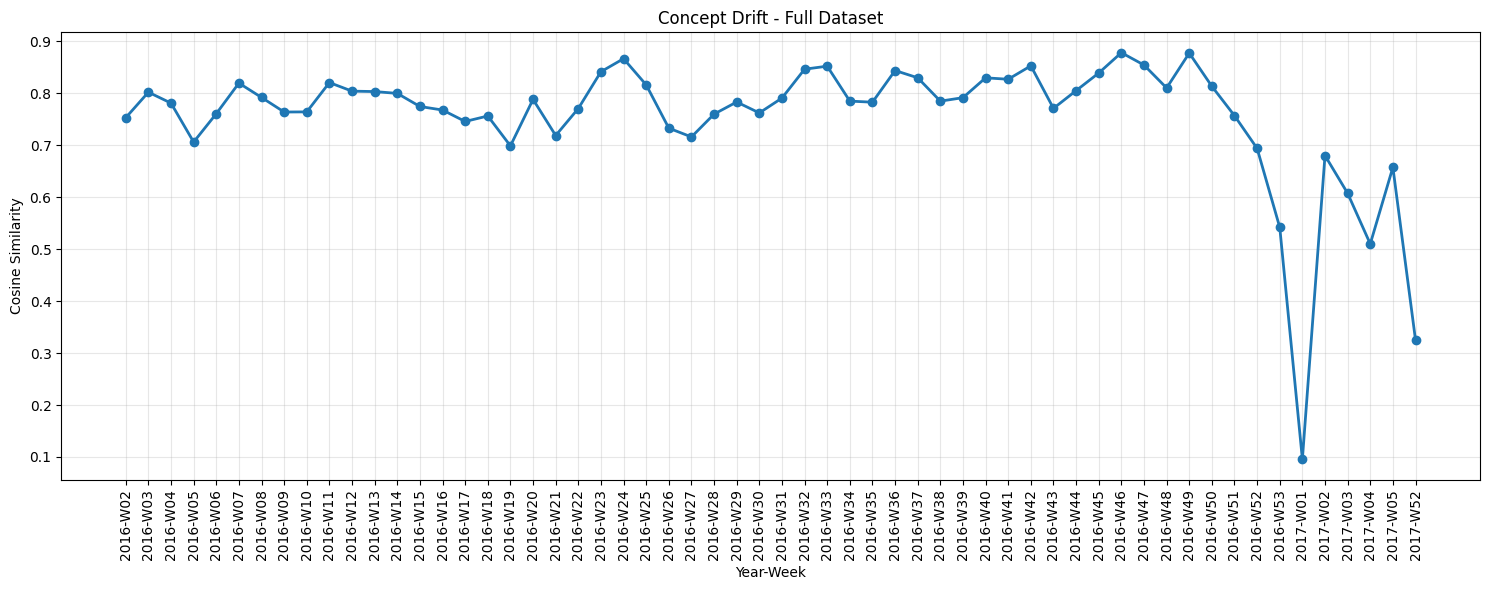

In [54]:
# ===================================================
# BIỂU ĐỒ 1: TOÀN BỘ DỮ LIỆU
# ===================================================
weekly_features_all = extract_weekly_features(df)

weeks, similarities, threshold, drift_weeks = compute_similarity(
    weekly_features_all
)

plot_drift(
    weeks,
    similarities,
    threshold,
    drift_weeks,
    "Concept Drift - Full Dataset"
)

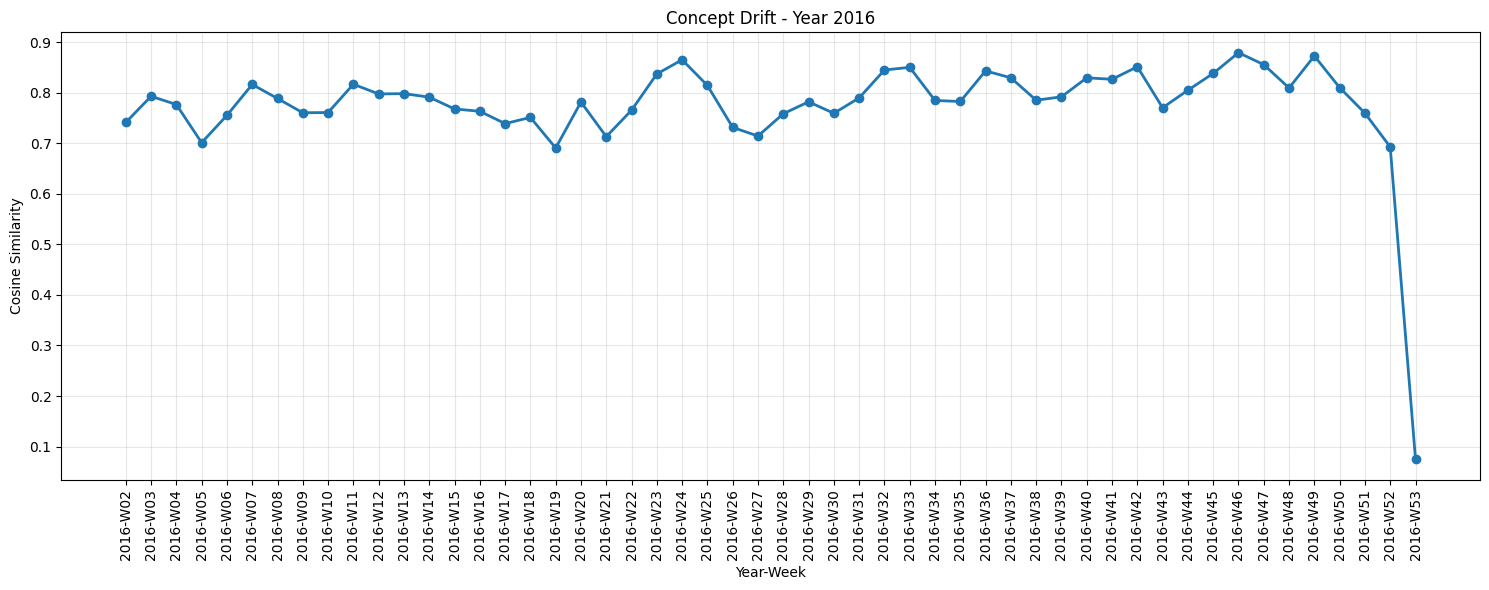

In [55]:
# ===================================================
# BIỂU ĐỒ 2: CHỈ NĂM 2016
# ===================================================
df_2016 = df[
    df['time:timestamp'].dt.year == 2016
].copy()

weekly_features_2016 = extract_weekly_features(
    df_2016
)

weeks, similarities, threshold, drift_weeks = compute_similarity(
    weekly_features_2016
)

plot_drift(
    weeks,
    similarities,
    threshold,
    drift_weeks,
    "Concept Drift - Year 2016"
)

Đang cô lập dữ liệu và tính toán đặc trưng cho 'W_Validate application'...


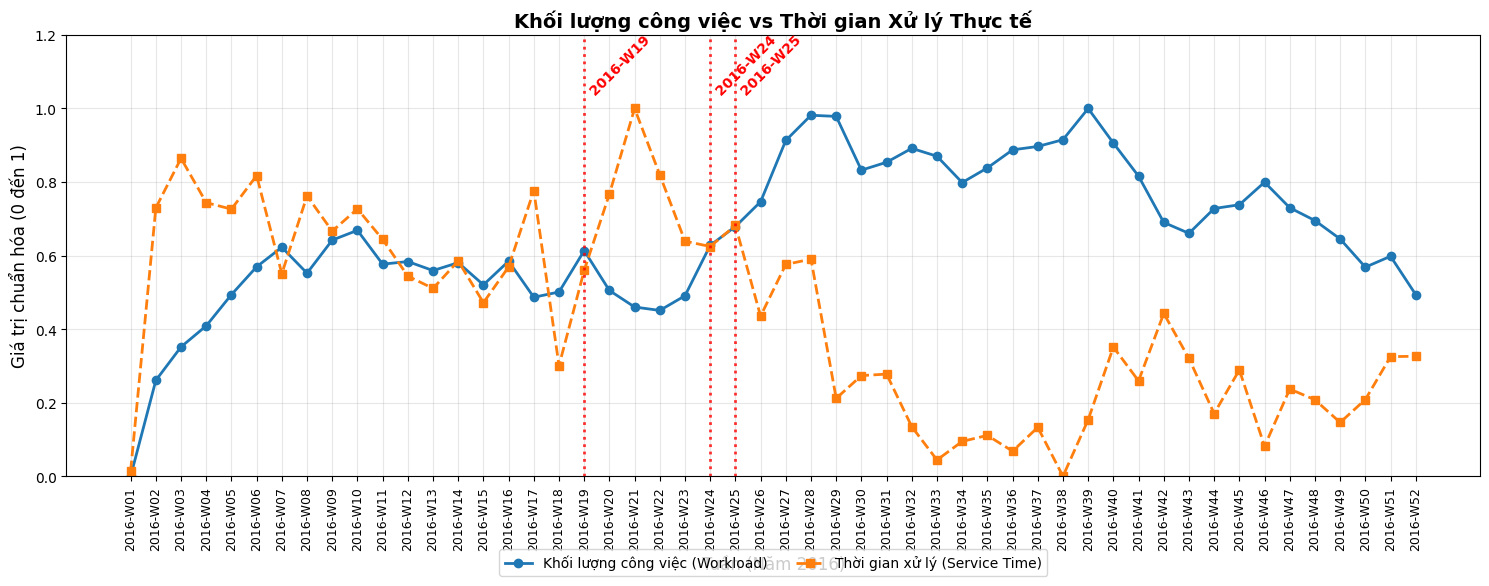

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("Đang cô lập dữ liệu và tính toán đặc trưng cho 'W_Validate application'...")

# 1. Cô lập dữ liệu: Chỉ lấy các sự kiện của khâu Thẩm định hồ sơ
# Lọc tác vụ Thẩm định VÀ chỉ lấy dữ liệu từ Tuần 52 năm 2016 trở về trước
df_validate = df[(df['concept:name'] == 'W_Validate application') & (df['YearWeek'] <= '2016-W52')].copy()
df_validate = df_validate.sort_values(by=['case:concept:name', 'time:timestamp'])

# 2. Tính Workload (Khối lượng công việc)
# Đếm số lượng hồ sơ (case) khác nhau được xử lý trong mỗi tuần
workload = df_validate.groupby('YearWeek')['case:concept:name'].nunique().rename('Workload')

# ==========================================
# 3. SỰ THAY ĐỔI: Tính Thời gian THỰC LÀM bằng lifecycle
# ==========================================
# Chuyển lifecycle về chữ thường để tránh lỗi viết hoa/thường
df_validate['lifecycle'] = df_validate['lifecycle:transition'].astype(str).str.lower()

# Tính độ lệch thời gian và lấy trạng thái lifecycle liền trước của CÙNG 1 hồ sơ
df_validate['prev_time'] = df_validate.groupby('case:concept:name')['time:timestamp'].shift(1)
df_validate['prev_lifecycle'] = df_validate.groupby('case:concept:name')['lifecycle'].shift(1)
df_validate['duration_hours'] = (df_validate['time:timestamp'] - df_validate['prev_time']).dt.total_seconds() / 3600

# BỘ LỌC CỐT LÕI: Chỉ lấy những đoạn nhân viên THỰC SỰ làm việc 
# (Kết thúc bằng complete/suspend và Bắt đầu bằng start/resume)
active_conditions = (
    df_validate['lifecycle'].isin(['complete', 'suspend']) & 
    df_validate['prev_lifecycle'].isin(['start', 'resume'])
)
df_active = df_validate[active_conditions]

# Tính tổng thời gian làm việc của mỗi hồ sơ trong tuần, sau đó lấy trung bình tuần
service_time_per_case = df_active.groupby(['YearWeek', 'case:concept:name'])['duration_hours'].sum().reset_index()
service_time = service_time_per_case.groupby('YearWeek')['duration_hours'].mean().rename('Service Time')

# 4. Gộp dữ liệu
df_plot = pd.concat([workload, service_time], axis=1).dropna()
# Chú ý: Đã bỏ dòng df_plot.iloc[:-1] vì ở Bước 1 ta đã chặn lấy tuần 53 rồi.

# 5. Chuẩn hóa dữ liệu về thang đo 0 - 1
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_plot)
df_scaled = pd.DataFrame(scaled_values, columns=df_plot.columns, index=df_plot.index)

# 6. Vẽ biểu đồ trực quan
plt.figure(figsize=(15, 6))

# Đường Workload (Khối lượng)
plt.plot(df_scaled.index, df_scaled['Workload'], 
         label='Khối lượng công việc (Workload)', color='#1f77b4', marker='o', linewidth=2)

# Đường Service Time (Thời gian xử lý)
plt.plot(df_scaled.index, df_scaled['Service Time'], 
         label='Thời gian xử lý (Service Time)', color='#ff7f0e', marker='s', linestyle='--', linewidth=2)

# Cắm cọc tiêu tại các tuần quan trọng theo bài báo (19, 20, 24, 25)
important_weeks = ['2016-W19', '2016-W24', '2016-W25']
for w in important_weeks:
    if w in df_scaled.index:
        plt.axvline(x=w, color='red', linestyle=':', linewidth=2, alpha=0.8)
        plt.text(w, 1.02, f' {w}', color='red', rotation=45, verticalalignment='bottom', fontweight='bold')

plt.title("Khối lượng công việc vs Thời gian Xử lý Thực tế", fontsize=14, fontweight='bold')
plt.xlabel("Tuần (Năm 2016)", fontsize=12)
plt.ylabel("Giá trị chuẩn hóa (0 đến 1)", fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.ylim(0, 1.2) # Mở rộng không gian phía trên để hiển thị nhãn
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

In [85]:
# Import thêm thư viện kiểm định thống kê (Nếu chưa cài, hãy chạy: pip install statsmodels)
from statsmodels.tsa.stattools import grangercausalitytests

print("\n" + "="*60)
print("BƯỚC 7: KIỂM ĐỊNH NHÂN QUẢ GRANGER (TÍNH P-VALUE)")
print("="*60)

print("Giả thuyết: Sự xáo trộn 'Workload' đóng vai trò là NGUYÊN NHÂN gây ra sự xáo trộn 'Service Time' với độ trễ 5 tuần.")

# 1. BIẾN ĐỔI DỮ LIỆU SANG DẠNG DỪNG (STATIONARY) BẰNG SAI PHÂN

# Tạo lại ma trận dữ liệu với chuỗi đã sai phân (Stationary Data)
# LƯU Ý: Cột 0 là Hậu quả (Service Time), Cột 1 là Nguyên nhân (Workload)
df_focused = df_scaled.loc['2016-W15':'2016-W45'].copy()
data_matrix = np.column_stack([
    df_focused['Service Time'].values, 
    df_focused['Workload'].values
])

# Các phần sau (lag_to_test = 5 và chạy thuật toán) giữ nguyên...

# 2. Thiết lập độ trễ (Time Lag) cần kiểm tra
lag_to_test = 1

try:
    # 3. Chạy thuật toán
    # Truyền maxlag=[5] để thuật toán chỉ test đích danh độ trễ 5 tuần, verbose=False để tắt log rác
    gc_res = grangercausalitytests(data_matrix, maxlag=[lag_to_test], verbose=False)
    
    # 4. Trích xuất P-value (Sử dụng kiểm định F-test - ssr_ftest)
    # Cấu trúc kết quả trả về là 1 dict, ta trích xuất p-value ở index 1 của ssr_ftest
    p_value = gc_res[lag_to_test][0]['ssr_ftest'][1]
    
    print(f"\nKẾT QUẢ KIỂM ĐỊNH:")
    print(f" -> Độ trễ (Lag): {lag_to_test} tuần (Phản ánh khoảng cách từ W24 đến W29)")
    print(f" -> P-value: {p_value:.6f}")
    
    # 5. Kết luận bằng Toán học
    if p_value < 0.05:
        print("\nKẾT LUẬN: Bác bỏ giả thuyết không (H0).")
        print(f"Toán học XÁC NHẬN có mối quan hệ NHÂN QUẢ cực kỳ mạnh mẽ (P-value < 0.05).")
        print("Sự gia tăng đột ngột của Khối lượng công việc chính là thủ phạm làm 'vỡ trận' Thời gian xử lý 5 tuần sau đó!")
    else:
        print("\nKẾT LUẬN: Không đủ bằng chứng thống kê.")
        print("Sự biến động này có thể chỉ là trùng hợp ngẫu nhiên (P-value >= 0.05).")
        
except Exception as e:
    print(f"Lỗi khi chạy kiểm định: Có thể do dữ liệu của bạn quá ngắn để tính lag=5. Chi tiết lỗi: {e}")


BƯỚC 7: KIỂM ĐỊNH NHÂN QUẢ GRANGER (TÍNH P-VALUE)
Giả thuyết: Sự xáo trộn 'Workload' đóng vai trò là NGUYÊN NHÂN gây ra sự xáo trộn 'Service Time' với độ trễ 5 tuần.

KẾT QUẢ KIỂM ĐỊNH:
 -> Độ trễ (Lag): 1 tuần (Phản ánh khoảng cách từ W24 đến W29)
 -> P-value: 0.081658

KẾT LUẬN: Không đủ bằng chứng thống kê.
Sự biến động này có thể chỉ là trùng hợp ngẫu nhiên (P-value >= 0.05).
